In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Apply the default theme
sns.set_theme()

In [28]:
# data_url = "https://raw.githubusercontent.com/dthonon/testeur_batterie/main/data/"
data_url = Path(os.getcwd()).parents[-5] / "data"
# Lecture du fichier CSV
data1 = pd.read_csv(data_url / "aquila_2000-001-01.csv")
data2 = pd.read_csv(data_url / "aquila_2000-001-02.csv")

In [30]:
# Ajouter une colonne "Temps" en heures et une colonne "Passe" pour identifier les deux DataFrames
data1["Temps"] = data1["Pas"] / 3600
data1["Passe"] = 1
data2["Temps"] = data2["Pas"] / 3600
data2["Passe"] = 2
# Séparer data en 2 DataFrames selon la valeur de la colonne "Contrôle"
data1_controle_0 = data1[data1["Contrôle"] == 0].copy()
data1_controle_1 = data1[data1["Contrôle"] == 1].copy()
data2_controle_0 = data2[data2["Contrôle"] == 0].copy()
data2_controle_1 = data2[data2["Contrôle"] == 1].copy()

In [31]:
win_size_0 = 5
data1_controle_0["V_smooth"] = data1_controle_0["V1(V)"].rolling(window=win_size_0, center=True).mean()
data1_controle_0["I_smooth"] = data1_controle_0["I(mA)"].rolling(window=win_size_0, center=True).mean()
data2_controle_0["V_smooth"] = data2_controle_0["V1(V)"].rolling(window=win_size_0, center=True).mean()
data2_controle_0["I_smooth"] = data2_controle_0["I(mA)"].rolling(window=win_size_0, center=True).mean()

win_size_1 = 61
data1_controle_1["V_smooth"] = data1_controle_1["V1(V)"].rolling(window=win_size_1, center=True).mean()
data1_controle_1["I_smooth"] = data1_controle_1["I(mA)"].rolling(window=win_size_1, center=True).mean()
data1_controle_1["E_smooth"] = data1_controle_1["E(mAh)"].rolling(window=win_size_1, center=True).mean()
data2_controle_1["V_smooth"] = data2_controle_1["V1(V)"].rolling(window=win_size_1, center=True).mean()
data2_controle_1["I_smooth"] = data2_controle_1["I(mA)"].rolling(window=win_size_1, center=True).mean()
data2_controle_1["E_smooth"] = data2_controle_1["E(mAh)"].rolling(window=win_size_1, center=True).mean()

In [33]:
data_controle_0 = pd.concat([data1_controle_0, data2_controle_0], ignore_index=True)
data_controle_1 = pd.concat([data1_controle_1, data2_controle_1], ignore_index=True)
print("Contrôle = 0 :", data_controle_0.shape[0], "lignes")
print("Contrôle = 1 :", data_controle_1.shape[0], "lignes")

Contrôle = 0 : 276 lignes
Contrôle = 1 : 165217 lignes


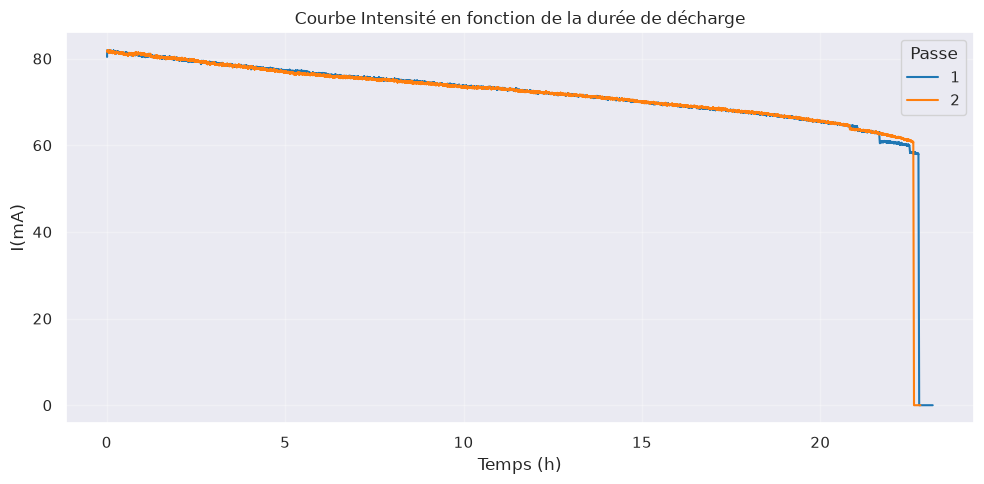

In [34]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=data_controle_1, x="Temps", y="I_smooth", hue="Passe", palette="tab10")
plt.xlabel("Temps (h)")
plt.ylabel("I(mA)")
plt.title("Courbe Intensité en fonction de la durée de décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

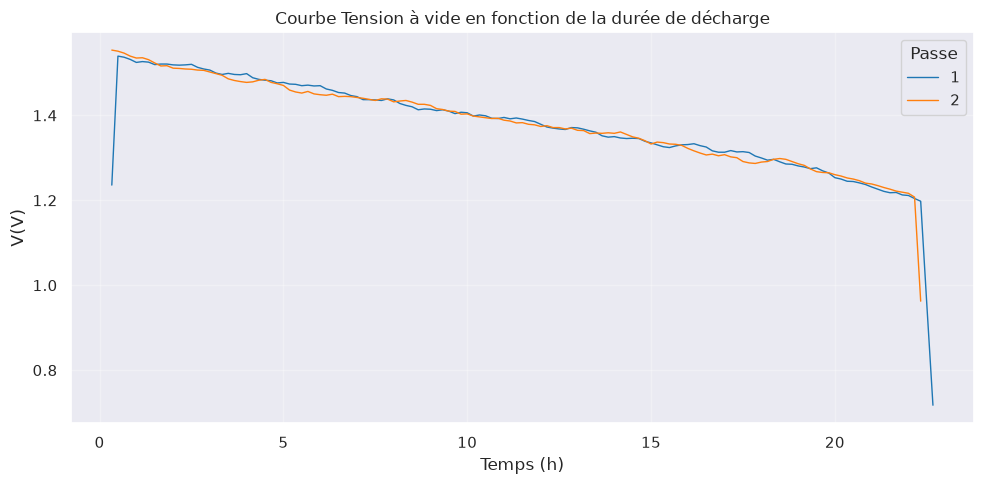

In [35]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=data_controle_0, x="Temps", y="V_smooth", hue="Passe", palette="tab10", marker="", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("V(V)")
plt.title("Courbe Tension à vide en fonction de la durée de décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

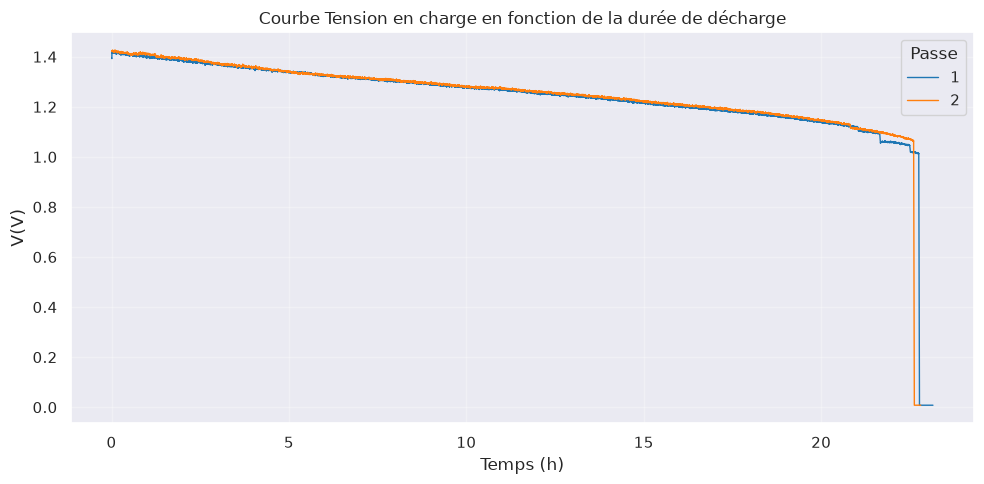

In [36]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=data_controle_1, x="Temps", y="V_smooth", hue="Passe", palette="tab10", marker="", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("V(V)")
plt.title("Courbe Tension en charge en fonction de la durée de décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

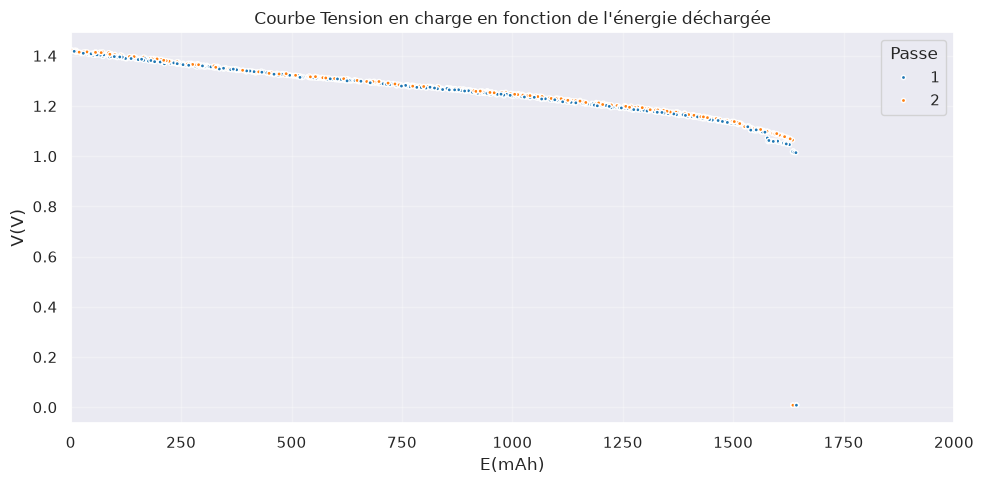

In [47]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data_controle_1.sample(n=1000), x="E_smooth", y="V_smooth", hue="Passe", marker=".", palette="tab10", linewidth=1)
plt.xlim(0, 2000)
plt.xlabel("E(mAh)")
plt.ylabel("V(V)")
plt.title("Courbe Tension en charge en fonction de l'énergie déchargée")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()